### To Build a Linear Regression model & predict the Exam_Score.

### `Objective:`

- Perform data preprocessing and basic EDA.
- Select appropriate numeric features.
- Train a Linear Regression model.
- Predict the Exam_Score.
- Evaluate the model using MAE, MSE, RMSE, and R² Score.

## Loading And Analyzing Dataset

In [2]:
import pandas as pd

In [ ]:
df = pd.read_csv("student_habits_performance.csv")

In [4]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

## Inspecting & Handling Missing Values

In [6]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [7]:
df.parental_education_level

0           Master
1      High School
2      High School
3           Master
4           Master
          ...     
995    High School
996    High School
997       Bachelor
998       Bachelor
999       Bachelor
Name: parental_education_level, Length: 1000, dtype: object

In [8]:
df.parental_education_level.value_counts()

parental_education_level
High School    392
Bachelor       350
Master         167
Name: count, dtype: int64

In [9]:
df.parental_education_level.unique()

array(['Master', 'High School', 'Bachelor', nan], dtype=object)

In [10]:
df.parental_education_level.mode()

0    High School
Name: parental_education_level, dtype: object

In [11]:
df.parental_education_level = df.parental_education_level.fillna(df.parental_education_level.mode()[0])

In [12]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

# Inspecting Duplicated Values

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Dropping Useless Column

In [15]:
df = df.drop("student_id",axis=1)

In [16]:
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Encoding Catergorical Columns

In [17]:
df.gender.unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [18]:
df.gender = df.gender.map({"Male" : 1, "Female" : 0, "Other" : 2})

In [19]:
df.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,0,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,1,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,0,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,0,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [20]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [23]:
# Automatically selects categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index(['part_time_job', 'diet_quality', 'parental_education_level',
       'internet_quality', 'extracurricular_participation'],
      dtype='object')

In [24]:
X_encoded = encoder.fit_transform(df[categorical_cols])

In [25]:
X_encoded

array([[1., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 1., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]], shape=(1000, 13))

In [26]:
encoder.get_feature_names_out()

array(['part_time_job_No', 'part_time_job_Yes', 'diet_quality_Fair',
       'diet_quality_Good', 'diet_quality_Poor',
       'parental_education_level_Bachelor',
       'parental_education_level_High School',
       'parental_education_level_Master', 'internet_quality_Average',
       'internet_quality_Good', 'internet_quality_Poor',
       'extracurricular_participation_No',
       'extracurricular_participation_Yes'], dtype=object)

In [29]:
categorical_encoded = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(),
)

In [30]:
categorical_encoded


,part_time_job_No,part_time_job_Yes,diet_quality_Fair,diet_quality_Good,diet_quality_Poor,parental_education_level_Bachelor,parental_education_level_High School,parental_education_level_Master,internet_quality_Average,internet_quality_Good,internet_quality_Poor,extracurricular_participation_No,extracurricular_participation_Yes
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
996,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
997,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
998,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Scaling Numerical Columns

In [ ]:
# Select All numeric columns

numeric_cols = df.drop("exam_score",axis=1)

numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols

Index(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'attendance_percentage', 'sleep_hours',
       'exercise_frequency', 'mental_health_rating', 'exam_score'],
      dtype='str')

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_scaled = scaler.fit_transform(df[numeric_cols.drop])

In [33]:
numeric_scaled

array([[ 1.08455114, -0.97616309, -2.41806844, ...,  1.46116644,
         0.90018637, -0.7939222 ],
       [-0.21586989, -0.97616309,  2.28170684, ...,  1.46116644,
         0.90018637,  1.80084647],
       [ 0.21760379,  0.76387807, -1.46449085, ..., -1.00868893,
        -1.55933923, -2.09130653],
       ...,
       [-0.21586989,  0.76387807, -0.37468788, ...,  0.96719536,
         1.25154717, -0.30814359],
       [ 1.51802481,  0.76387807,  1.26001656, ..., -1.50266001,
        -1.55933923,  0.00583527],
       [-0.64934357, -0.97616309,  0.51077703, ..., -0.51471786,
         0.90018637,  0.31388999]], shape=(1000, 10))

In [34]:
scaler.get_feature_names_out()

array(['age', 'gender', 'study_hours_per_day', 'social_media_hours',
       'netflix_hours', 'attendance_percentage', 'sleep_hours',
       'exercise_frequency', 'mental_health_rating', 'exam_score'],
      dtype=object)

In [35]:
numeric_scaled = pd.DataFrame(
    numeric_scaled,
    columns=scaler.get_feature_names_out(),
)

In [36]:
numeric_scaled

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
0,1.084551,-0.976163,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,-0.793922
1,-0.215870,-0.976163,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,1.800846
2,0.217604,0.763878,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,-2.091307
3,1.084551,-0.976163,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,-2.535616
4,-0.649344,-0.976163,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,-0.189661
...,...,...,...,...,...,...,...,...,...,...
995,0.217604,-0.976163,-0.647139,-1.711417,-0.204452,-0.759132,0.840211,-0.514718,0.197465,0.384980
996,-1.516291,-0.976163,-0.442801,-1.284736,0.540025,0.198871,0.269138,-1.008689,0.197465,-0.219282
997,-0.215870,0.763878,-0.374688,0.080643,-0.483631,-2.366448,0.024393,0.967195,1.251547,-0.308144
998,1.518025,0.763878,1.260017,1.360685,-0.669750,1.689097,0.921793,-1.502660,-1.559339,0.005835


## Merging Encoded Categorical & Scaled Numerical Columns 

In [39]:
df = pd.concat([numeric_scaled, categorical_encoded], axis=1) # Means merging on columns not rows.

In [43]:
df.drop("exam_score", axis=1, inplace=True)   

In [44]:
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,part_time_job_No,...,diet_quality_Good,diet_quality_Poor,parental_education_level_Bachelor,parental_education_level_High School,parental_education_level_Master,internet_quality_Average,internet_quality_Good,internet_quality_Poor,extracurricular_participation_No,extracurricular_participation_Yes
0,1.084551,-0.976163,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,1.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,-0.215870,-0.976163,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.217604,0.763878,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
3,1.084551,-0.976163,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,-0.649344,-0.976163,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.217604,-0.976163,-0.647139,-1.711417,-0.204452,-0.759132,0.840211,-0.514718,0.197465,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
996,-1.516291,-0.976163,-0.442801,-1.284736,0.540025,0.198871,0.269138,-1.008689,0.197465,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
997,-0.215870,0.763878,-0.374688,0.080643,-0.483631,-2.366448,0.024393,0.967195,1.251547,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
998,1.518025,0.763878,1.260017,1.360685,-0.669750,1.689097,0.921793,-1.502660,-1.559339,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [55]:
df

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,part_time_job_No,...,diet_quality_Poor,parental_education_level_Bachelor,parental_education_level_High School,parental_education_level_Master,internet_quality_Average,internet_quality_Good,internet_quality_Poor,extracurricular_participation_No,extracurricular_participation_Yes,exam_score
0,1.084551,-0.976163,-2.418068,-1.114064,-0.669750,0.092426,1.248120,1.461166,0.900186,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,56.2
1,-0.215870,-0.976163,2.281707,0.251315,0.446965,1.401696,-1.525661,1.461166,0.900186,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,100.0
2,0.217604,0.763878,-1.464491,0.507324,-0.483631,1.135584,1.248120,-1.008689,-1.559339,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,34.3
3,1.084551,-0.976163,-1.736942,1.190013,-0.762810,-1.397800,2.227102,0.473224,-1.559339,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,26.8
4,-0.649344,-0.976163,0.987566,1.616694,-1.228108,0.720450,-1.280916,-0.020747,-1.559339,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,66.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.217604,-0.976163,-0.647139,-1.711417,-0.204452,-0.759132,0.840211,-0.514718,0.197465,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,76.1
996,-1.516291,-0.976163,-0.442801,-1.284736,0.540025,0.198871,0.269138,-1.008689,0.197465,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,65.9
997,-0.215870,0.763878,-0.374688,0.080643,-0.483631,-2.366448,0.024393,0.967195,1.251547,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,64.4
998,1.518025,0.763878,1.260017,1.360685,-0.669750,1.689097,0.921793,-1.502660,-1.559339,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,69.7


## Visualizing

In [58]:
import matplotlib.pyplot as plt

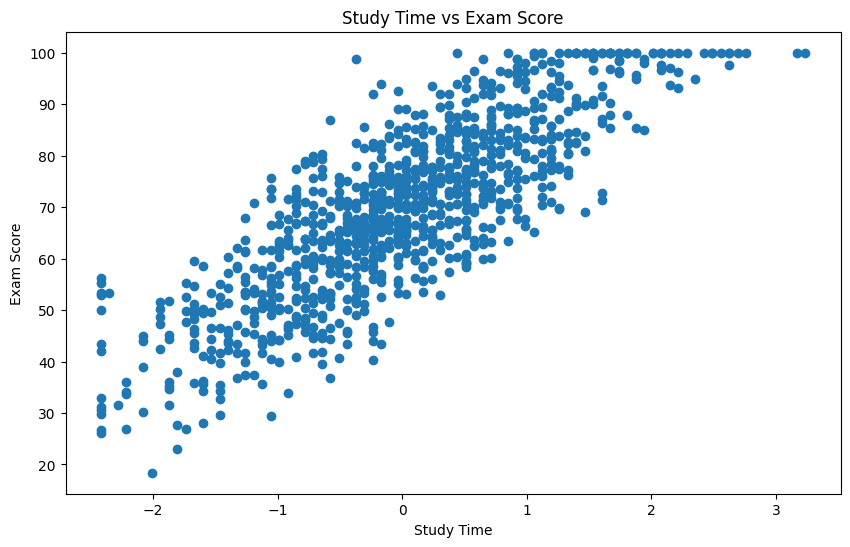

In [81]:
plt.figure(figsize=(10, 6))
plt.scatter(df['study_hours_per_day'], df['exam_score'])
plt.title('Study Time vs Exam Score')
plt.xlabel('Study Time')
plt.ylabel('Exam Score')
plt.show()

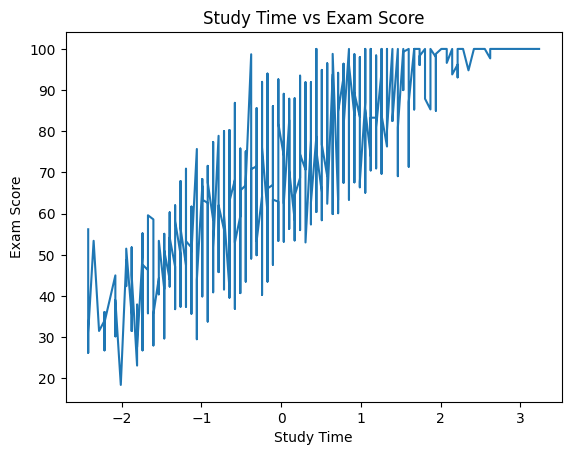

In [83]:
df_sorted = df.sort_values('study_hours_per_day')
plt.plot(df_sorted['study_hours_per_day'], df_sorted['exam_score'])
plt.xlabel('Study Time')
plt.ylabel('Exam Score')
plt.title('Study Time vs Exam Score')
plt.show()

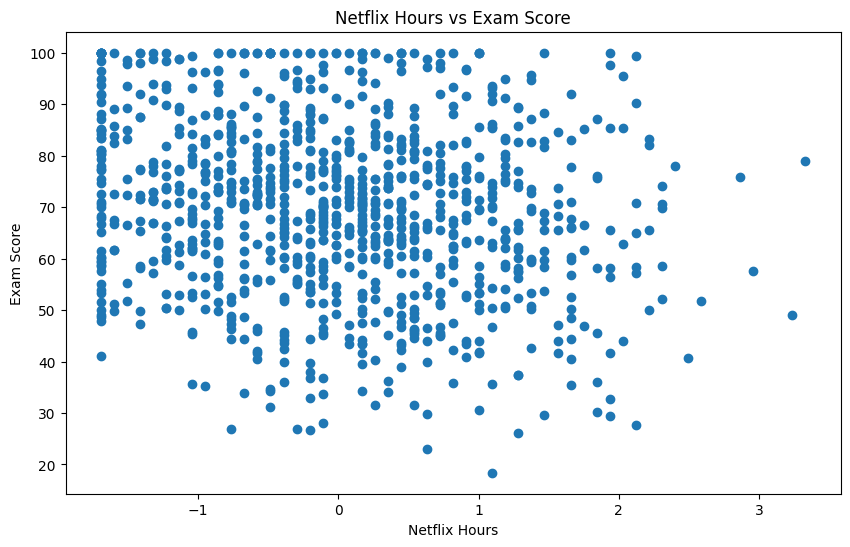

In [67]:
plt.figure(figsize=(10, 6))
plt.scatter(df['netflix_hours'], df['exam_score'])
plt.title('Netflix Hours vs Exam Score')
plt.xlabel('Netflix Hours')
plt.ylabel('Exam Score')
plt.show()

## Importing Dependencies For Model

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score 

## Splitting the dataset into features and target variable

In [90]:
X = df.drop("exam_score", axis=1)
y = df["exam_score"]

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training Our Linear Model

In [92]:
model = LinearRegression()

In [93]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [94]:
y_pred = model.predict(X_test)

## Evaluating Model

In [95]:
mean_absolute_error(y_test, y_pred)

4.189064503173751

In [96]:
mean_squared_error(y_test, y_pred)

26.527835418018135

In [97]:
root_mean_squared_error(y_test, y_pred)

5.150517975700904

In [98]:
r2_score(y_test, y_pred)

0.8965490428667341

## Evaluation Results:

- **R2 score : 89.6%**
- **MAE : 4.18**
- **MSE : 26.5**
- **RMSE : 5.15**

------------------
END
---------------------------